# DMT EEG Preprocessing Pipeline

*   Dataset: Zenodo 10.5281/zenodo.3992359
*   Goal: Load BDF files, clean signal, extract band power features

In [3]:
# =============================================================================
# DMT EEG Preprocessing Pipeline
# Dataset: Zenodo 10.5281/zenodo.3992359
# Goal: Load BDF files, clean signal, extract band power features
# =============================================================================

# --- 0. Install dependencies (run this cell first in Colab) -----------------
# !pip install mne pandas numpy scipy

import mne
import numpy as np
import pandas as pd
from pathlib import Path
import urllib.request
import os

mne.set_log_level("WARNING")  # suppress verbose MNE output

# =============================================================================
# 1. CONFIGURATION
# =============================================================================

ZENODO_BASE = "https://zenodo.org/records/3992359/files"

# Exact filenames from Zenodo — mixed separators and case
# S21 skipped — its DMT file is .xdf format (different loader needed)
SUBJECTS = [
    ("S01",  "S01-DMT"),
    ("S02",  "S02_DMT"),
    ("S03",  "S03-DMT"),
    ("S04",  "s04-DMT"),
    ("S05",  "s05-DMT"),
    ("S06",  "S06_DMT"),
    ("S07f", "S07_DMT"),
    ("S08",  "S08_DMT"),
    ("S09",  "S09_DMT"),
    ("S10",  "S10_DMT"),
    ("S11",  "S11-DMT"),
    ("S12",  "S12-DMT"),
    ("S13",  "S13-DMT"),
    ("S14",  "S14-DMT"),
    ("S15",  "S15-DMT"),
    ("S16",  "S16_DMT"),
    ("S17",  "S17_DMT"),
    ("S18",  "S18_DMT"),
    ("S19",  "S19_DMT"),
    ("S20",  "S20_DMT"),
    ("S22",  "S22-DMT"),
    ("S23",  "S23-DMT"),
    ("S24",  "S24-DMT"),
    ("S25",  "S25_DMT"),
    ("S26",  "S26_DMT"),
    ("S27",  "S27_DMT"),
    ("S28",  "S28_DMT"),
    ("S29",  "S29-DMT"),
    ("S30",  "S30-DMT"),
    ("S31",  "S31-DMT"),
    ("S32",  "S32-DMT"),
    ("S33",  "S33-DMT"),
    ("S34",  "S34-DMT"),
    ("S35",  "S35-DMT"),
]

DATA_DIR = Path("data/raw")
OUTPUT_DIR = Path("data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# EEG band definitions (Hz)
BANDS = {
    "delta":  (1, 4),
    "theta":  (4, 8),
    "alpha":  (8, 12),
    "beta":   (12, 30),
    "gamma":  (30, 45),
}

SFREQ_TARGET = 256    # downsample target (original is 500 Hz)
L_FREQ = 1.0          # high-pass filter
H_FREQ = 45.0         # low-pass filter
EPOCH_DURATION = 4.0  # seconds per epoch
N_ICA = 15            # ICA components (keep below channel rank)

# =============================================================================
# 2. DOWNLOAD BDF FILES
# =============================================================================

def download_subject(subject_id, filename_prefix):
    """Download a single subject's BDF file from Zenodo if not already cached."""
    fname = DATA_DIR / f"{filename_prefix}.bdf"
    if fname.exists():
        print(f"  {subject_id}: already cached, skipping download.")
        return fname
    url = f"{ZENODO_BASE}/{filename_prefix}.bdf?download=1"
    print(f"  {subject_id}: downloading...")
    urllib.request.urlretrieve(url, fname)
    return fname

# =============================================================================
# 3. PREPROCESS SINGLE SUBJECT
# =============================================================================

def preprocess_subject(subject_id, filename_prefix):
    """
    Full preprocessing for one subject:
    1. Load BDF
    2. Pick EEG channels only
    3. Bandpass filter (1-45 Hz)
    4. Downsample to 256 Hz
    5. Re-reference to average
    6. ICA artifact removal
    7. Epoch into fixed-length segments
    8. Extract band power features per epoch
    Returns: feature matrix (n_epochs x n_features)
    """
    fname = download_subject(subject_id, filename_prefix)

    # --- Load ---
    raw = mne.io.read_raw_bdf(fname, preload=True, verbose=False)

    # --- Pick EEG channels only ---
    raw.pick_types(eeg=True, stim=False, exclude="bads")

    # --- Bandpass filter ---
    raw.filter(L_FREQ, H_FREQ, fir_design="firwin", verbose=False)

    # --- Downsample ---
    raw.resample(SFREQ_TARGET, verbose=False)

    # --- Average reference ---
    raw.set_eeg_reference("average", projection=True, verbose=False)
    raw.apply_proj()

    # --- ICA artifact removal ---
    # n_components=15 avoids instability from large variance ratio
    # No EOG channels in these files so auto eye-blink detection is skipped
    ica = mne.preprocessing.ICA(n_components=N_ICA, random_state=42, max_iter="auto")
    ica.fit(raw, verbose=False)
    ica.apply(raw, verbose=False)

    # --- Epoch into fixed-length segments ---
    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=EPOCH_DURATION,
        overlap=0.0,
        preload=True,
        verbose=False
    )

    # --- Band power features ---
    features = extract_band_power(epochs)
    return features

# =============================================================================
# 4. BAND POWER FEATURE EXTRACTION
# =============================================================================

def extract_band_power(epochs):
    """
    Compute mean band power per channel per epoch using Welch PSD.
    Output shape: (n_epochs, n_channels * n_bands)
    """
    from mne.time_frequency import psd_array_welch

    data = epochs.get_data()   # (n_epochs, n_channels, n_times)
    sfreq = epochs.info["sfreq"]

    psds, freqs = psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=1.0,
        fmax=45.0,
        n_fft=int(sfreq * EPOCH_DURATION),
        verbose=False
    )
    # psds shape: (n_epochs, n_channels, n_freqs)

    band_powers = []
    for band_name, (fmin, fmax) in BANDS.items():
        freq_mask = (freqs >= fmin) & (freqs <= fmax)
        bp = psds[:, :, freq_mask].mean(axis=-1)  # (n_epochs, n_channels)
        band_powers.append(bp)

    # Stack: (n_epochs, n_channels * n_bands)
    features = np.concatenate(band_powers, axis=1)
    return features

# =============================================================================
# 5. BUILD FULL FEATURE MATRIX
# =============================================================================

def build_dataset():
    """
    Process all subjects and return:
    - X: feature matrix (n_total_epochs, n_features)
    - subject_ids: subject label per epoch (for cross-validation grouping)
    """
    all_features = []
    all_subjects = []

    for subject_id, filename_prefix in SUBJECTS:
        print(f"Processing {subject_id}...")
        try:
            features = preprocess_subject(subject_id, filename_prefix)
            all_features.append(features)
            all_subjects.extend([subject_id] * len(features))
            print(f"  {subject_id}: {features.shape[0]} epochs, {features.shape[1]} features")
        except Exception as e:
            print(f"  {subject_id}: FAILED — {e}")

    X = np.vstack(all_features)
    subject_ids = np.array(all_subjects)

    np.save(OUTPUT_DIR / "X_band_power.npy", X)
    np.save(OUTPUT_DIR / "subject_ids.npy", subject_ids)
    print(f"\nDone. Feature matrix shape: {X.shape}")
    return X, subject_ids

# =============================================================================
# 6. ATTACH NDE LABELS
# =============================================================================

def attach_labels(subject_ids, labels_csv="nde_labels.csv"):
    """
    Match each epoch to its subject's NDE scores.
    Returns label DataFrame aligned to X rows.
    """
    labels_df = pd.read_csv(labels_csv, index_col="Subject")

    y_total, y_cogn, y_afect, y_paran, y_trasc = [], [], [], [], []

    for sid in subject_ids:
        row = labels_df.loc[sid]
        y_total.append(row["NDE-Total"])
        y_cogn.append(row["NDE-Cogn"])
        y_afect.append(row["NDE-Afect"])
        y_paran.append(row["NDE-Paran"])
        y_trasc.append(row["NDE-Trasc"])

    labels = pd.DataFrame({
        "Subject":   subject_ids,
        "NDE-Total": y_total,
        "NDE-Cogn":  y_cogn,
        "NDE-Afect": y_afect,
        "NDE-Paran": y_paran,
        "NDE-Trasc": y_trasc,
    })

    labels.to_csv(OUTPUT_DIR / "y_labels.csv", index=False)
    print(f"Labels saved. Shape: {labels.shape}")
    return labels

# =============================================================================
# 7. RUN
# =============================================================================

if __name__ == "__main__":
    X, subject_ids = build_dataset()
    nde_labels = "/content/nde_labels.csv"
    labels = attach_labels(subject_ids, labels_csv=nde_labels)
    print("\nReady for modeling.")
    print(f"X shape: {X.shape}")
    print(f"Labels shape: {labels.shape}")
    print(labels["NDE-Total"].describe())

Processing S01...
  S01: already cached, skipping download.
  S01: 156 epochs, 120 features
Processing S02...
  S02: already cached, skipping download.
  S02: 105 epochs, 120 features
Processing S03...
  S03: already cached, skipping download.
  S03: 89 epochs, 120 features
Processing S04...
  S04: already cached, skipping download.
  S04: 152 epochs, 120 features
Processing S05...
  S05: already cached, skipping download.
  S05: 98 epochs, 120 features
Processing S06...
  S06: already cached, skipping download.
  S06: 111 epochs, 120 features
Processing S07f...
  S07f: already cached, skipping download.
  S07f: 103 epochs, 120 features
Processing S08...
  S08: already cached, skipping download.
  S08: 111 epochs, 120 features
Processing S09...
  S09: already cached, skipping download.
  S09: 95 epochs, 120 features
Processing S10...
  S10: already cached, skipping download.
  S10: 79 epochs, 120 features
Processing S11...
  S11: already cached, skipping download.
  S11: 76 epochs, 120

/tmp/ipykernel_940/2306838896.py:138: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (24) and smallest (1.1e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 5
  ica.fit(raw, verbose=False)


  S23: 207 epochs, 120 features
Processing S24...
  S24: already cached, skipping download.
  S24: 183 epochs, 120 features
Processing S25...
  S25: already cached, skipping download.
  S25: 82 epochs, 120 features
Processing S26...
  S26: already cached, skipping download.
  S26: 116 epochs, 120 features
Processing S27...
  S27: already cached, skipping download.
  S27: 139 epochs, 120 features
Processing S28...
  S28: already cached, skipping download.
  S28: 130 epochs, 120 features
Processing S29...
  S29: already cached, skipping download.
  S29: 110 epochs, 120 features
Processing S30...
  S30: already cached, skipping download.
  S30: 147 epochs, 120 features
Processing S31...
  S31: already cached, skipping download.
  S31: 108 epochs, 120 features
Processing S32...
  S32: already cached, skipping download.
  S32: 129 epochs, 120 features
Processing S33...
  S33: already cached, skipping download.
  S33: 112 epochs, 120 features
Processing S34...
  S34: already cached, skipping

In [4]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Load saved data
X = np.load("data/processed/X_band_power.npy")
y = labels["NDE-Total"].values
groups = labels["Subject"].values

# Leave-One-Subject-Out cross validation
# This is the correct CV strategy for EEG — no subject leaks into test set
logo = LeaveOneGroupOut()

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVR(kernel="rbf", C=1.0, epsilon=0.1))
])

scores = cross_val_score(
    pipeline, X, y,
    groups=groups,
    cv=logo,
    scoring="r2"
)

print(f"LOSO R² scores: {scores}")
print(f"Mean R²: {scores.mean():.3f} ± {scores.std():.3f}")

LOSO R² scores: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.87845520e+26
  0.00000000e+00 -1.51370406e+27  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
Mean R²: -50045575752580419383459840.000 ± 256757546347446879880478720.000


In [6]:
from google.colab import drive
drive.mount('/drive')

import shutil

import os
os.makedirs("/drive/MyDrive/liminal-eeg", exist_ok=True)

shutil.copy("data/processed/X_band_power.npy", "/drive/MyDrive/liminal-eeg/X_band_power.npy")
shutil.copy("data/processed/y_labels.csv", "/drive/MyDrive/liminal-eeg/y_labels.csv")
shutil.copy("data/processed/subject_ids.npy", "/drive/MyDrive/liminal-eeg/subject_ids.npy")
print("Saved to Drive.")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Saved to Drive.


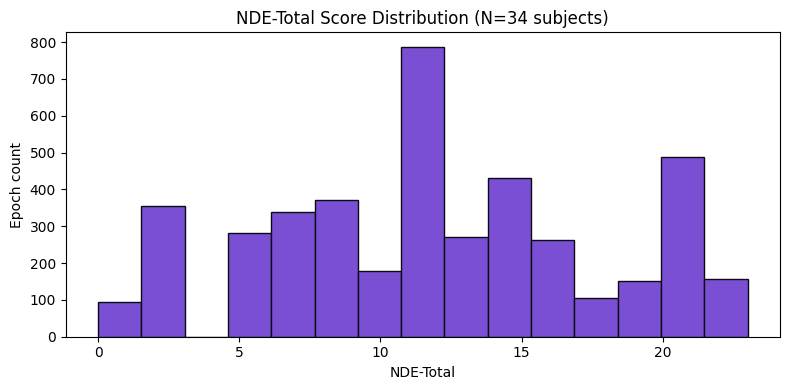

Subject
S09      0.0
S23      3.0
S35      3.0
S20      5.0
S22      6.0
S19      7.0
S32      7.0
S02      7.0
S33      8.0
S11      8.0
S24      9.0
S15     10.0
S03     11.0
S07f    11.0
S34     11.0
S06     12.0
S31     12.1
S30     12.1
S29     12.1
S01     13.0
S26     13.0
S28     14.0
S10     14.0
S25     15.0
S27     15.0
S08     16.0
S17     16.0
S12     17.0
S04     19.0
S05     20.0
S14     20.0
S13     21.0
S18     21.0
S16     23.0
Name: NDE-Total, dtype: float64


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(labels["NDE-Total"], bins=15, color="#7b4fd4", edgecolor="#0a0a14")
plt.title("NDE-Total Score Distribution (N=34 subjects)")
plt.xlabel("NDE-Total")
plt.ylabel("Epoch count")
plt.tight_layout()
plt.show()

print(labels.groupby("Subject")["NDE-Total"].first().sort_values())

In [8]:
assert len(X) == len(labels), "Mismatch between features and labels"
print(f"X: {X.shape}")
print(f"y: {labels.shape}")
print(f"Subjects: {labels['Subject'].nunique()}")
print(f"NDE-Total range: {labels['NDE-Total'].min():.1f} – {labels['NDE-Total'].max():.1f}")
print("Alignment confirmed.")

X: (4273, 120)
y: (4273, 6)
Subjects: 34
NDE-Total range: 0.0 – 23.0
Alignment confirmed.
